<a href="https://colab.research.google.com/github/lldb14/Sinais-Biol-gicas/blob/main/Tarefa_1_Sinais_Biol%C3%B3gicos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Um conjunto de dados de frequência cardíaca instantânea e acelerometria de várias noites com rótulos de estágio do sono por EEG.

Dados de sono de 47 voluntários adultos saudáveis, sem histórico de distúrbios do sono, recrutados na comunidade local por meio de panfletos de divulgação do estudo. O protocolo do estudo foi aprovado pelo Comitê de Ética em Pesquisa da Universidade de Massachusetts Lowell. Os participantes foram selecionados sem levar em consideração sexo ou etnia e forneceram consentimento livre e esclarecido por escrito. Cada participante usou simultaneamente uma faixa de cabeça Dreem 2 e um Apple Watch por até sete noites consecutivas, totalizando 253 noites de dados.

O conjunto de dados contém gravações de várias noites da frequência cardíaca instantânea e da acelerometria de 3 eixos do Apple Watch, juntamente com rótulos dos estágios do sono derivados do EEG Dreem 2 e classificados de acordo com o padrão AASM (Vigília, N1, N2, N3, REM).

Este recurso apoia o desenvolvimento e a validação de métodos de classificação dos estágios do sono baseados em dispositivos vestíveis, a modelagem multimodal de sinais de frequência cardíaca e movimento e pesquisas que se beneficiam de dados de sono de várias noites.

Song, T. (2026). A Multi-Night Instantaneous Heart Rate and Accelerometry Dataset with EEG Sleep Stage Labels (version 1.0.0). PhysioNet. RRID:SCR_007345. https://doi.org/10.13026/a0sy-7t69

## Dados

O conjunto de dados está organizado em 47 pastas de nível de sujeito, com cada pasta contendo entre 3 e 7 noites de dados brutos. Para cada noite, são fornecidos três arquivos: *motion.csv, hr.csv*, e *labels.mat*.

1. motion.csv : Dados do acelerômetro de três eixos (x, y, z) registrados pelo Apple Watch. Cada linha inclui um registro de data e hora em tempo Unix (segundos, com precisão de subsegundos) indicando quando a medição foi registrada.

2. hr.csv : Valores de frequência cardíaca instantânea (FCI) derivados do sensor PPG do Apple Watch via HealthKit. A FCI é medida em batimentos por minuto (bpm) em pontos de tempo específicos, com uma taxa de amostragem aproximada de 0,2 Hz. Cada linha inclui um registro de data e hora em tempo Unix (segundos, com precisão de subsegundos).

3. labels.mat : Contém três variáveis-chave:
- recStart: Marca de tempo que indica o início da gravação.

- dreem_labelAnotações automatizadas dos estágios do sono obtidas pelo dispositivo Dreem, codificadas como números inteiros (0 = Acordado, 1 = N1, 2 = N2, 3 = N3, 4 = REM, 5 = Desconhecido).

- expert_label Anotações manuais das fases do sono feitas por um especialista em sono usando o mesmo esquema de codificação.

https://physionet.org/content/bidsleep-dataset/1.0.0/

# Amostra

- HR: como a amostragem é de ~0,2 Hz (1 amostra a cada ~5 s), uma janela curta (ex: 30 s) mostraria só 5–6 pontos — pouco informativo. Por isso usei 10 minutos (600 s), o suficiente para ver oscilações da frequência cardíaca ao longo de um trecho do sono.

- Motion: o acelerômetro tem taxa de amostragem bem mais alta, então a mesma janela de 600 s também funciona bem para ver eventos de movimento (picos = agitação/mudança de posição) e trechos de repouso (linha quase reta).

In [29]:
!wget -r -N -c -np -q --show-progress \
  https://physionet.org/files/bidsleep-dataset/1.0.0/Bidslab00/

!find physionet.org/files/bidsleep-dataset/1.0.0/Bidslab00 -type f

physionet.org/files     [ <=>                ]    1008  --.-KB/s    in 0s      
physionet.org/files     [ <=>                ]     604  --.-KB/s    in 0s      
physionet.org/files     [ <=>                ]     604  --.-KB/s    in 0s      
physionet.org/files     [ <=>                ]     604  --.-KB/s    in 0s      
physionet.org/files     [ <=>                ]     604  --.-KB/s    in 0s      
physionet.org/files     [ <=>                ]     604  --.-KB/s    in 0s      
physionet.org/files     [ <=>                ]     604  --.-KB/s    in 0s      
physionet.org/files     [ <=>                ]     604  --.-KB/s    in 0s      
physionet.org/files/bidsleep-dataset/1.0.0/Bidslab00/5/hr.csv
physionet.org/files/bidsleep-dataset/1.0.0/Bidslab00/5/labels.mat
physionet.org/files/bidsleep-dataset/1.0.0/Bidslab00/5/motion.csv
physionet.org/files/bidsleep-dataset/1.0.0/Bidslab00/5/index.html
physionet.org/files/bidsleep-dataset/1.0.0/Bidslab00/1/hr.csv
physionet.org/files/bidsleep-dataset/1

In [39]:
import pandas as pd
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
from datetime import datetime

# --- Caminhos (ajuste a noite: 1, 2, 3...) ---
base = "physionet.org/files/bidsleep-dataset/1.0.0/Bidslab00/1"

hr = pd.read_csv(f"{base}/hr.csv", header=None)
hr.columns = ["time", "bpm"]
motion = pd.read_csv(f"{base}/motion.csv")
motion = motion.rename(columns={'Timestamp': 'time'})
labels = loadmat(f"{base}/labels.mat")

# --- Conferir nomes reais das colunas (ajuste se necessário) ---
print("Colunas HR:", hr.columns.tolist())
print("Colunas Motion:", motion.columns.tolist())

# Renomeie SE PRECISAR, conforme o print acima. Exemplo (ajuste os nomes reais):
# hr.columns = ["time", "bpm"]
# motion.columns = ["time", "x", "y", "z"]

# --- Labels ---
# Convert the datetime string to a datetime object, then to a Unix timestamp
rec_start_str = labels["recStart"][0] # Access the string from the array
rec_start_dt = datetime.strptime(rec_start_str, '%Y-%m-%d %H:%M:%S')
rec_start = rec_start_dt.timestamp()

dreem_label = labels["dreem_label"].flatten()
expert_label = labels["expert_label"].flatten()

# --- Alinhamento correto (fórmula oficial da documentação) ---
# k = floor((t - recStart)/30) + 1   → k é 1-based
def epoca_por_tempo(t, rec_start):
    k = np.floor((t - rec_start) / 30).astype(int) + 1
    return k

hr["epoca"] = epoca_por_tempo(hr["time"].values, rec_start)
motion["epoca"] = epoca_por_tempo(motion["time"].values, rec_start)

# Estágio de sono correspondente a cada amostra (k-1 pois array numpy é 0-based)
n_epocas = len(expert_label)
hr = hr[(hr["epoca"] >= 1) & (hr["epoca"] <= n_epocas)].copy()
motion = motion[(motion["epoca"] >= 1) & (motion["epoca"] <= n_epocas)].copy()

hr["estagio"] = expert_label[hr["epoca"].values - 1]
motion["estagio"] = expert_label[motion["epoca"].values - 1]

# --- Tempo relativo ao início (segundos) ---
hr["t_rel"] = hr["time"] - rec_start
motion["t_rel"] = motion["time"] - rec_start

# --- Janela de análise ---
# Adjust t_ini and t_fim to match the actual range of available data
# Take the minimum t_rel from the hr data and define a 600s window from there
if not hr.empty:
    t_ini = hr["t_rel"].min()
else:
    t_ini = 0 # Default if hr is empty, though it shouldn't be here
t_fim = t_ini + 600  # segundos (10 min) — ajuste conforme necessário

hr_win = hr[(hr["t_rel"] >= t_ini) & (hr["t_rel"] <= t_fim)]
motion_win = motion[(motion["t_rel"] >= t_ini) & (motion["t_rel"] <= t_fim)]

# Hipnograma na mesma janela
epoca_ini = int(np.floor(t_ini / 30)) + 1
epoca_fim = int(np.floor(t_fim / 30)) + 1
epocas_win = np.arange(epoca_ini, epoca_fim + 1)
epocas_win = epocas_win[(epocas_win >= 1) & (epocas_win <= n_epocas)]
tempos_hipno = (epocas_win - 1) * 30
estagios_win = expert_label[epocas_win - 1]

# --- Mapeamento de estágios para rótulos legíveis ---
nomes_estagio = {0: "Wake", 1: "N1", 2: "N2", 3: "N3", 4: "REM", 5: "Desconhecido"}

Colunas HR: ['time', 'bpm']
Colunas Motion: ['time', 'x', 'y', 'z']


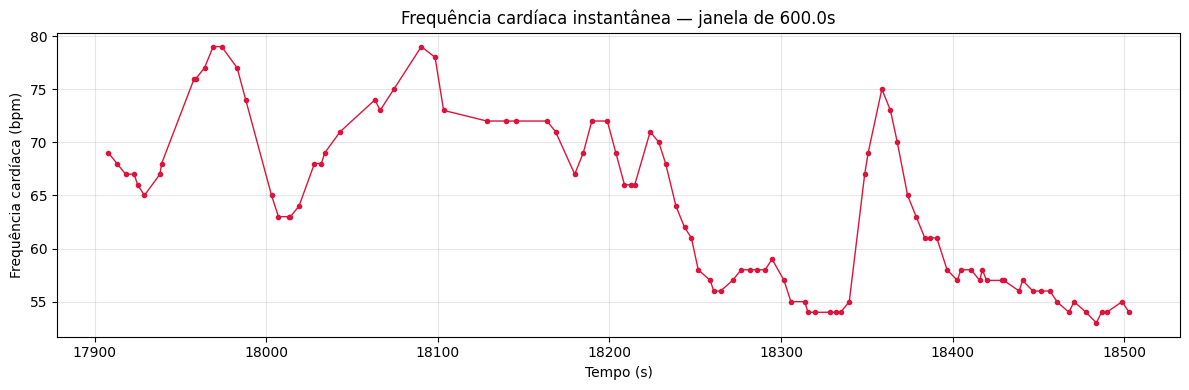

In [43]:
# --- Plot: Frequência cardíaca ---
plt.figure(figsize=(12, 4))
plt.plot(hr_win["t_rel"], hr_win["bpm"], color="crimson", marker="o", markersize=3, linewidth=1)
plt.xlabel("Tempo (s)")
plt.ylabel("Frequência cardíaca (bpm)")
plt.title(f"Frequência cardíaca instantânea — janela de {t_fim - t_ini}s")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

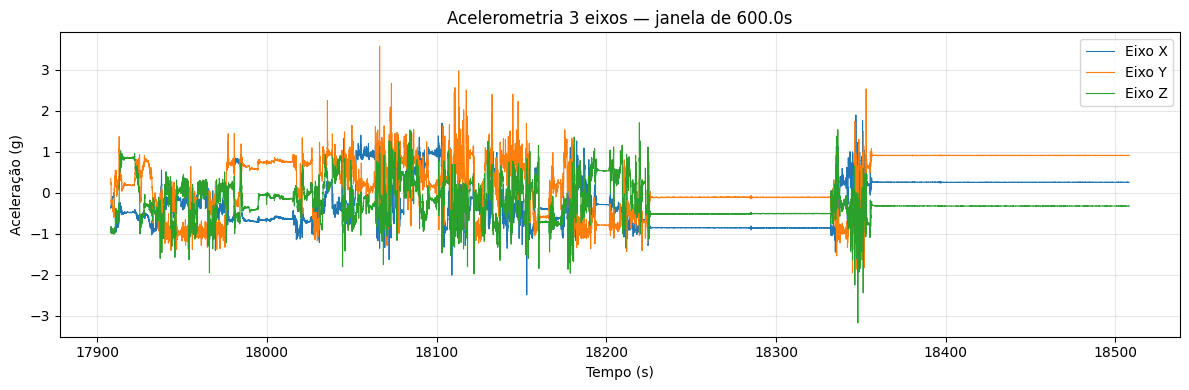

In [44]:
# --- Plot: Acelerometria (3 eixos) ---
plt.figure(figsize=(12, 4))
plt.plot(motion_win["t_rel"], motion_win["x"], label="Eixo X", linewidth=0.8)
plt.plot(motion_win["t_rel"], motion_win["y"], label="Eixo Y", linewidth=0.8)
plt.plot(motion_win["t_rel"], motion_win["z"], label="Eixo Z", linewidth=0.8)
plt.xlabel("Tempo (s)")
plt.ylabel("Aceleração (g)")  # confirme a unidade no seu dado; Apple Watch geralmente reporta em g
plt.title(f"Acelerometria 3 eixos — janela de {t_fim - t_ini}s")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [45]:
print("Primeiro tempo do HR:", hr["time"].min())
print("recStart:", rec_start)
print("Diferença:", hr["time"].min() - rec_start)

Primeiro tempo do HR: 1638504593.0297956
recStart: 1638486685.0
Diferença: 17908.029795646667
